In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import random
from datetime import datetime, timedelta, date
import holidays as hl
import time

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

import openmeteo_requests
import requests_cache
from retry_requests import retry

## Bring in Data  

In [2]:
au = pd.read_csv("data_weather/Final/Auckland_Pedestrian_Daily.csv")
db = pd.read_csv("data_weather/Final/Dublin_Pedestrian_Daily.csv")

df = pd.concat([au, db],ignore_index=True)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Location_ID','Date'])
display(df[df['Location_ID'].str.contains('IRDUB')].head(2))
display(df[df['Location_ID'].str.contains('NZAUK')].head(2))

,Country,City,Location_ID,Location_Name,Type_of_Attraction,Attraction_Category,Latitude,Longitude,Date,PedsSen_Count,Weather_Temperature,Weather_Wind_Gust,Weather_Relative_Humidity,Weather_Precipitation,Is_Holiday
7304,Ireland,Dublin,IRDUB_1,Trinity College & Book of Kells,University,Cultural,53.3438,-6.254,2021-01-01,33648.0,3.6995,30.810,87.58997,1.2,1
7305,Ireland,Dublin,IRDUB_1,Trinity College & Book of Kells,University,Cultural,53.3438,-6.254,2021-01-02,38277.0,2.4745,31.095,86.96619,0.5,0


,Country,City,Location_ID,Location_Name,Type_of_Attraction,Attraction_Category,Latitude,Longitude,Date,PedsSen_Count,Weather_Temperature,Weather_Wind_Gust,Weather_Relative_Humidity,Weather_Precipitation,Is_Holiday
0,New Zealand,Auckland,NZAUK_1,Sky Tower,Observation Tower,Entertainment,-36.8485,174.7633,2021-01-01,36620.0,18.858334,18.749998,78.877710,0.700000,1
1,New Zealand,Auckland,NZAUK_1,Sky Tower,Observation Tower,Entertainment,-36.8485,174.7633,2021-01-02,35415.0,18.966665,19.724998,86.536705,15.800002,1


In [3]:
LOOKBACK = 30
TARGET = "PedsSen_Count"
DATE = "Date"
LOC_COL = "Location_ID"

## Train XGBoost baseline (tabular)


In [5]:
def add_fEng_colums_xgb(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    shifted = df[TARGET].shift(1)

    # Common lag/rolling features from past values only
    df["lag1"] = shifted
    df["lag7"] = df[TARGET].shift(7)
    df["lag14"] = df[TARGET].shift(14)
    df["roll7"] = shifted.rolling(7, min_periods=1).mean()
    df["roll14"] = shifted.rolling(14, min_periods=1).mean()
    df["ewma60"] = shifted.ewm(halflife=60, adjust=False).mean()
    return df

def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df[DATE] = pd.to_datetime(df[DATE])
    df["dow_sin"] = np.sin(2 * np.pi * df[DATE].dt.dayofweek / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df[DATE].dt.dayofweek / 7)
    df["doy_sin"] = np.sin(2 * np.pi * df[DATE].dt.dayofyear / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * df[DATE].dt.dayofyear / 365.25)
    df["is_weekend"] = (df[DATE].dt.dayofweek >= 5).astype(int)
    return df

def column_removal(df:pd.DataFrame)->pd.DataFrame:
    return df.drop(columns=['Country','City','Location_ID','Location_Name','Type_of_Attraction','Attraction_Category','Latitude','Longitude','Date'])

def featurize_block_xgb(raw_df: pd.DataFrame) -> pd.DataFrame:
    return column_removal(add_calendar_features(add_fEng_colums_xgb(raw_df))).reset_index(drop=True)

def featurize_with_history_xgb(history_raw: pd.DataFrame, future_raw: pd.DataFrame) -> pd.DataFrame:
    combined = pd.concat([history_raw, future_raw], ignore_index=True)
    combined_fe = featurize_block_xgb(combined)
    return combined_fe.iloc[len(history_raw):].reset_index(drop=True)

def eval_original_metrics_from_arrays(y_true: np.ndarray, y_pred: np.ndarray, n_features: int) -> dict:
    y_true = np.asarray(y_true, dtype=np.float64).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=np.float64).reshape(-1)

    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(root_mean_squared_error(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))

    n = int(len(y_true))
    p = int(n_features)
    if (n - p - 1) > 0 and not np.isnan(r2):
        adj_r2 = float(1.0 - (1.0 - r2) * (n - 1) / (n - p - 1))
    else:
        adj_r2 = np.nan

    return {"mse": mse, "rmse": rmse, "mae": mae, "r2": r2, "adj_r2": adj_r2}

XGB_CONFIGS = {
    "val_months": 4,
    "n_estimators": 2500,
    "learning_rate": 0.03,
    "max_depth": 3,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.3,
    "reg_lambda": 2.0,
    "gamma": 0.05,
    "early_stopping_rounds": 80,
}

xgb_model_summaries = {}

for loc in df["Location_ID"].unique():
    print(f"Training XGB model {loc}")
    sub = df[df["Location_ID"] == loc].sort_values(DATE).reset_index(drop=True)

    end = sub[DATE].max()
    test_start = end - pd.DateOffset(months=6) + pd.Timedelta(days=1)

    trainval_raw_all = sub[sub[DATE] < test_start].copy()
    test_raw = sub[sub[DATE] >= test_start].copy()

    best = {"val_rmse": np.inf, "val_adj_r2": -np.inf,"payload": None}
    
    for i in range(6, 55, 6):
        window_start = test_start - pd.DateOffset(months=i)
        sub2 = trainval_raw_all[trainval_raw_all[DATE] >= window_start].copy()

        min_needed_rows = max(180, int((XGB_CONFIGS["val_months"] + 2) * 30))
        if len(sub2) < min_needed_rows:
            continue

        val_start = sub2[DATE].max() - pd.DateOffset(months=XGB_CONFIGS["val_months"]) + pd.Timedelta(days=1)
        train_raw = sub2[sub2[DATE] < val_start].copy()
        val_raw = sub2[sub2[DATE] >= val_start].copy()

        if len(train_raw) < 60 or len(val_raw) == 0:
            continue

        train = featurize_block_xgb(train_raw)
        val = featurize_with_history_xgb(train_raw, val_raw)

        features = [c for c in train.columns if c != TARGET]

        imputer = SimpleImputer(strategy="median")
        X_train = imputer.fit_transform(train[features])
        X_val = imputer.transform(val[features])

        y_train_log = np.log1p(train[TARGET].to_numpy(dtype=np.float32))
        y_val_log = np.log1p(val[TARGET].to_numpy(dtype=np.float32))

        model = XGBRegressor(
            objective="reg:squarederror", # Regression loss
            n_estimators=XGB_CONFIGS["n_estimators"], # Max Number of tree
            learning_rate=XGB_CONFIGS["learning_rate"], # Small step is size pre tree 
            max_depth=XGB_CONFIGS["max_depth"], # Reduce overfitting
            min_child_weight=XGB_CONFIGS["min_child_weight"], # Reduce noise by blockign splits that are too small
            subsample=XGB_CONFIGS["subsample"], # Robustness, sees 80% of the rows
            colsample_bytree=XGB_CONFIGS["colsample_bytree"], # Reduces overfitting/correlation, see 80% of features
            reg_alpha=XGB_CONFIGS["reg_alpha"], # L1 reg
            reg_lambda=XGB_CONFIGS["reg_lambda"], # L2 reg
            gamma=XGB_CONFIGS["gamma"], # Min gain needed to make a split
            random_state=SEED,
            tree_method="hist", # Faster Histogram-based trainning
            early_stopping_rounds=XGB_CONFIGS["early_stopping_rounds"], # Stop if validation dosen't improve after 80 round, actual tree used are much less(best_tree)
        )

        model.fit(
            X_train,
            y_train_log,
            eval_set=[(X_val, y_val_log)],
            verbose=False,
        )

        val_pred = np.clip(np.expm1(model.predict(X_val)), 0, None)
        val_true = val[TARGET].to_numpy(dtype=np.float32)
        val_metrics = eval_original_metrics_from_arrays(val_true, val_pred, len(features))

        best_iter = getattr(model, "best_iteration", None)
        if best_iter is None:
            best_trees = model.get_params().get("n_estimators", XGB_CONFIGS["n_estimators"])
        else:
            best_trees = int(best_iter) + 1

        if val_metrics["rmse"] < best["val_rmse"]:
            best["val_rmse"] = val_metrics["rmse"]
            best["val_adj_r2"] = val_metrics["adj_r2"]
            best["payload"] = {
                "months": i,
                "features": features,
                "best_trees": int(best_trees),
                "train_raw": train_raw,
                "val_raw": val_raw,
                "val_metrics": val_metrics,
                "params": model.get_params(),
            }

    if best["payload"] is None:
        print(f"No valid XGB window for {loc}")
        continue

    b = best["payload"]
    full_raw = pd.concat([b["train_raw"], b["val_raw"]], ignore_index=True)

    full_fe = featurize_block_xgb(full_raw)
    features = b["features"]

    imputer = SimpleImputer(strategy="median")
    X_full = imputer.fit_transform(full_fe[features])
    y_full_log = np.log1p(full_fe[TARGET].to_numpy(dtype=np.float32))

    final_params = dict(b["params"])
    final_params.pop("early_stopping_rounds", None)
    final_params["n_estimators"] = b["best_trees"]
    final_model = XGBRegressor(**final_params)
    final_model.fit(X_full, y_full_log, verbose=False)

    # Test uses proper history at feature boundary
    test = featurize_with_history_xgb(full_raw, test_raw)
    X_test = imputer.transform(test[features])
    y_test_true = test[TARGET].to_numpy(dtype=np.float32)
    y_test_pred = np.clip(np.expm1(final_model.predict(X_test)), 0, None)

    y_train_pred = np.clip(np.expm1(final_model.predict(X_full)), 0, None)
    y_train_true = full_fe[TARGET].to_numpy(dtype=np.float32)

    metrics = {
        "train": eval_original_metrics_from_arrays(y_train_true, y_train_pred, len(features)),
        "val": b["val_metrics"],
        "test": eval_original_metrics_from_arrays(y_test_true, y_test_pred, len(features)),
    }

    bundle = {
        "location_id": str(loc),
        "features": features,
        "imputer": imputer,
        "model": final_model,
        "best_window_months": int(b["months"]),
        "best_trees": int(b["best_trees"]),
        "last_history_raw": full_raw.tail(90).copy().reset_index(drop=True),
        "metrics": metrics,
    }

    os.makedirs("xgb_models", exist_ok=True)
    pkl_path = os.path.join("xgb_models", f"{loc}.pkl")

    with open(pkl_path, "wb") as f:
        pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

    xgb_model_summaries[pkl_path] = bundle
    print(f"Stored XGB Summary -> {pkl_path}")
    print(f"Best months: {b['months']} | Trees: {b['best_trees']}")
    print("Train:", bundle["metrics"]["train"])
    print("Val  :", bundle["metrics"]["val"])
    print("Test :", bundle["metrics"]["test"])
    print("------------------------------------")

    # break

Training XGB model IRDUB_1
Stored XGB Summary -> xgb_models\IRDUB_1.pkl
Best months: 54 | Trees: 520
Train: {'mse': 156568020.71019745, 'rmse': 12512.714362207644, 'mae': 9383.968326545371, 'r2': 0.9388288318161131, 'adj_r2': 0.9382265310832256}
Val  : {'mse': 100918586.63795446, 'rmse': 10045.82433839824, 'mae': 8179.703125, 'r2': 0.784585881142827, 'adj_r2': 0.7517608725550673}
Test : {'mse': 128871575.7500816, 'rmse': 11352.161721455592, 'mae': 8599.833644701086, 'r2': 0.8045868403132912, 'adj_r2': 0.7858646214211514}
------------------------------------
Training XGB model IRDUB_3
Stored XGB Summary -> xgb_models\IRDUB_3.pkl
Best months: 48 | Trees: 349
Train: {'mse': 48397998.03143498, 'rmse': 6956.866969508255, 'mae': 5142.6909276608485, 'r2': 0.9243639348274169, 'adj_r2': 0.9235258620831223}
Val  : {'mse': 34825280.99962466, 'rmse': 5901.294857878622, 'mae': 4666.981397284836, 'r2': 0.7566800988521603, 'adj_r2': 0.7196027805820132}
Test : {'mse': 57406836.308100805, 'rmse': 7576.

## Test a model (try to simulate production)

In [6]:
# ============================================================
# OPEN-METEO SETUP
# ============================================================
cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

In [7]:
def get_weather_forecast(lat, lon) -> pd.DataFrame:
    """
    Returns a DataFrame with:
      Date,
      Weather_Temperature,
      Weather_Wind_Gust,
      Weather_Relative_Humidity,
      Weather_Precipitation
    """
    HsRg = (date.today() - date(date.today().year, 1, 1)).days
    FcRg = 217
    plength = HsRg + FcRg
    dates = pd.date_range(pd.Timestamp(datetime(date.today().year, 1, 1, 0, 0, 0)), periods=plength, freq="D")

    # Past (archive)
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": dates[0].strftime("%Y-%m-%d"),
        "end_date": dates[HsRg-1].strftime("%Y-%m-%d"),
        "daily": ["temperature_2m_mean", "wind_gusts_10m_mean", "relative_humidity_2m_mean", "precipitation_sum"],
        "timezone": "auto",
    }
    while True:
        try:
            responses = openmeteo.weather_api(url, params=params)
            break
        except Exception as e:
            print(f"Openmeto retry Past {e}", end="", flush=True)
            time.sleep(60)
            print("", end="", flush=True)

    dly = responses[0].Daily()
    T1 = dly.Variables(0).ValuesAsNumpy()
    W1 = dly.Variables(1).ValuesAsNumpy()
    R1 = dly.Variables(2).ValuesAsNumpy()
    P1 = dly.Variables(3).ValuesAsNumpy()

    # Future (seasonal)
    url = "https://seasonal-api.open-meteo.com/v1/seasonal"
    params = {
        "latitude": lat,
        "longitude": lon,
        "forecast_days": FcRg,
        "timezone": "auto",
        "daily": ["temperature_2m_mean", "wind_gusts_10m_mean", "relative_humidity_2m_mean", "precipitation_sum"],
    }
    while True:
        try:
            responses = openmeteo.weather_api(url, params=params)
            break
        except Exception as e:
            print(f"Openmeto retry Future {e}", end="", flush=True)
            time.sleep(60)
            print("", end="", flush=True)

    dly = responses[0].Daily()
    T2 = dly.Variables(0).ValuesAsNumpy()
    W2 = dly.Variables(1).ValuesAsNumpy()
    R2 = dly.Variables(2).ValuesAsNumpy()
    P2 = dly.Variables(3).ValuesAsNumpy()

    T = np.concatenate((T1, T2)).T
    W = np.concatenate((W1, W2)).T
    R = np.concatenate((R1, R2)).T
    P = np.concatenate((P1, P2)).T

    df =  pd.DataFrame(
        {
            "Date": dates,
            "Weather_Temperature": T,
            "Weather_Wind_Gust": W,
            "Weather_Relative_Humidity": R,  
            "Weather_Precipitation": P,      
        }
    )

    df = df.dropna(how='any', axis='index') # can go up to max fc but results with NaN, will drop them
    return df

In [8]:
def get_holidays(country_code,wx) -> pd.DataFrame:
    cal = hl.country_holidays(country=country_code)
    wx['Is_Holiday'] = wx['Date'].apply(lambda x: 1 if cal.get(x) != None else 0)
    return wx 

In [9]:
def add_calendar_features_future(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["dow_sin"] = np.sin(2 * np.pi * df["Date"].dt.dayofweek / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["Date"].dt.dayofweek / 7)
    df["doy_sin"] = np.sin(2 * np.pi * df["Date"].dt.dayofyear / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * df["Date"].dt.dayofyear / 365.25)
    df["is_weekend"] = (df["Date"].dt.dayofweek >= 5).astype(int)
    return df

In [10]:
(date.today() - date(date.today().year, 1, 1))

datetime.timedelta(days=73)

In [11]:
(date.today() - timedelta(days=1) - date(date.today().year, 1, 1)).days

72

In [12]:
def load_location_pickle(pkl_path: str):
    with open(pkl_path, "rb") as f:
        bundle = pickle.load(f)
    return bundle

In [14]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)


def _init_ewma_state(history: list[float], halflife: float) -> tuple[float, float]:
    alpha = 1.0 - np.exp(np.log(0.5) / halflife)
    if not history:
        return 0.0, alpha

    state = float(history[0])
    for v in history[1:]:
        state = alpha * float(v) + (1.0 - alpha) * state
    return state, alpha


def forecast_for_location(pkl_path: str, lat: float, lon: float, country_code: str) -> pd.DataFrame:
    """
    Loads an XGB location bundle, builds future exogenous inputs (weather+holiday+calendar),
    and performs recursive forecasting using lag/rolling/EWMA features.

    Returns Date formatted as YYYY-MM-DD.
    """
    bundle = load_location_pickle(pkl_path)

    features = bundle["features"]
    imputer = bundle["imputer"]
    model = bundle["model"]

    history_raw = bundle["last_history_raw"].copy().reset_index(drop=True)

    history = [float(v) for v in history_raw[TARGET].dropna().tolist()]

    ewma60_state, alpha60 = _init_ewma_state(history, halflife=60.0)
    use_ewma30 = "ewma30" in features
    if use_ewma30:
        ewma30_state, alpha30 = _init_ewma_state(history, halflife=30.0)

    # Build exogenous future inputs
    wx = get_weather_forecast(lat, lon)
    wx["Date"] = pd.to_datetime(wx["Date"]).dt.normalize()

    hol = get_holidays(country_code, wx)
    fut = add_calendar_features_future(hol)

    preds = []

    def lag(k: int) -> float:
        if len(history) >= k:
            return float(history[-k])
        return float(history[0])

    for i in range(fut.shape[0]):
        row = fut.iloc[i]
        new = pd.Series(index=features, dtype="float64")

        # Lag/rolling/EWMA features (matching training definitions)
        if "lag1" in features:
            new["lag1"] = lag(1)
        if "lag7" in features:
            new["lag7"] = lag(7)
        if "lag14" in features:
            new["lag14"] = lag(14)
        if "lag28" in features:
            new["lag28"] = lag(28)

        if "roll7" in features:
            new["roll7"] = float(np.mean(history[-7:]))
        if "roll14" in features:
            new["roll14"] = float(np.mean(history[-14:]))
        if "roll30" in features:
            new["roll30"] = float(np.mean(history[-30:]))

        if "ewma60" in features:
            new["ewma60"] = float(ewma60_state)
        if use_ewma30:
            new["ewma30"] = float(ewma30_state)

        # Weather
        new["Weather_Temperature"] = float(row["Weather_Temperature"])
        new["Weather_Wind_Gust"] = float(row["Weather_Wind_Gust"])
        new["Weather_Relative_Humidity"] = float(row["Weather_Relative_Humidity"])
        new["Weather_Precipitation"] = float(row["Weather_Precipitation"])

        # Holiday/calendar
        new["Is_Holiday"] = int(row["Is_Holiday"])
        new["dow_sin"] = float(row["dow_sin"])
        new["dow_cos"] = float(row["dow_cos"])
        new["doy_sin"] = float(row["doy_sin"])
        new["doy_cos"] = float(row["doy_cos"])
        new["is_weekend"] = int(row["is_weekend"])

        # Predict in log-space model, then invert with expm1
        X_one = pd.DataFrame([new], columns=features)
        X_one = imputer.transform(X_one)
        pred_log = float(model.predict(X_one)[0])
        pred = float(np.clip(np.expm1(pred_log), 0.0, None))
        preds.append(pred)

        # Update recursive state with predicted value
        history.append(pred)
        ewma60_state = alpha60 * pred + (1.0 - alpha60) * ewma60_state
        if use_ewma30:
            ewma30_state = alpha30 * pred + (1.0 - alpha30) * ewma30_state

    out = fut.copy()
    out.insert(1, TARGET, np.round(preds, 0))
    out["Date"] = out["Date"].dt.strftime("%Y-%m-%d")

    keep_cols = [
        "Date",
        TARGET,
        "Weather_Temperature",
        "Weather_Wind_Gust",
        "Weather_Relative_Humidity",
        "Weather_Precipitation",
        "Is_Holiday",
    ]
    return out[keep_cols]

In [15]:
filename =[('./xgb_models/IRDUB_1.pkl',53.3438,-6.254,'IE','IRDUB_1'),
           ('./xgb_models/IRDUB_3.pkl',53.3382,-6.2591,'IE','IRDUB_3'),
           ('./xgb_models/IRDUB_4.pkl',53.3455,-6.2643,'IE','IRDUB_4'),
           ('./xgb_models/IRDUB_5.pkl',53.3429,-6.2674,'IE','IRDUB_5'),
           ('./xgb_models/IRDUB_8.pkl',53.3471,-6.2416,'IE','IRDUB_8'),
           ('./xgb_models/NZAUK_1.pkl',-36.8485,174.7633,'NZ','NZAUK_1'),
           ('./xgb_models/NZAUK_5.pkl',-36.8443,174.767,'NZ','NZAUK_5'),
           ('./xgb_models/NZAUK_6.pkl',-36.8475,174.8316,'NZ','NZAUK_6'),
           ('./xgb_models/NZAUK_7.pkl',-36.8531,174.8506,'NZ','NZAUK_7')]

--------------------------------------------------------------------------IRDUB_1


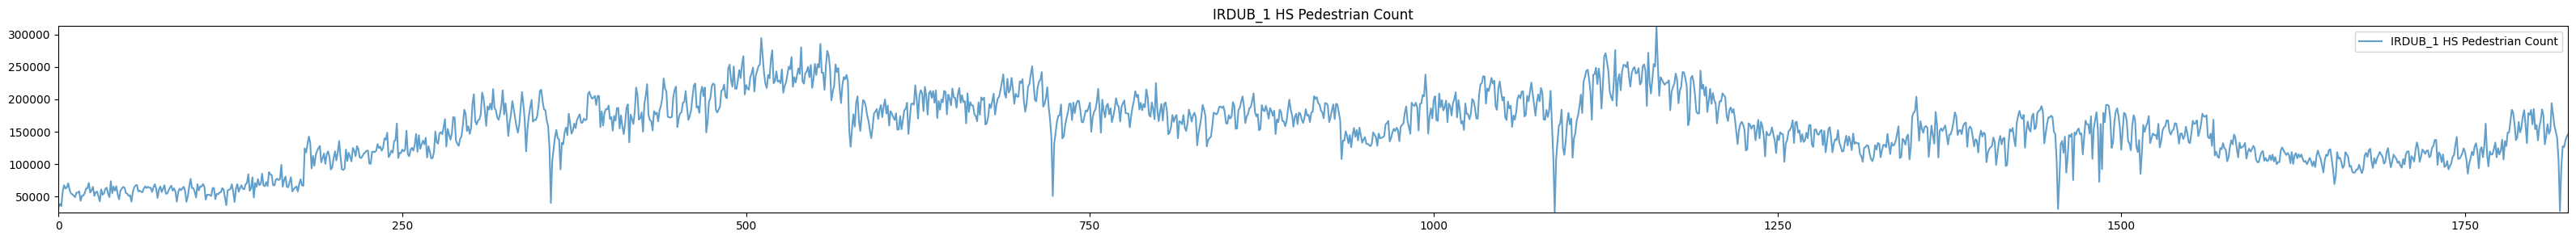

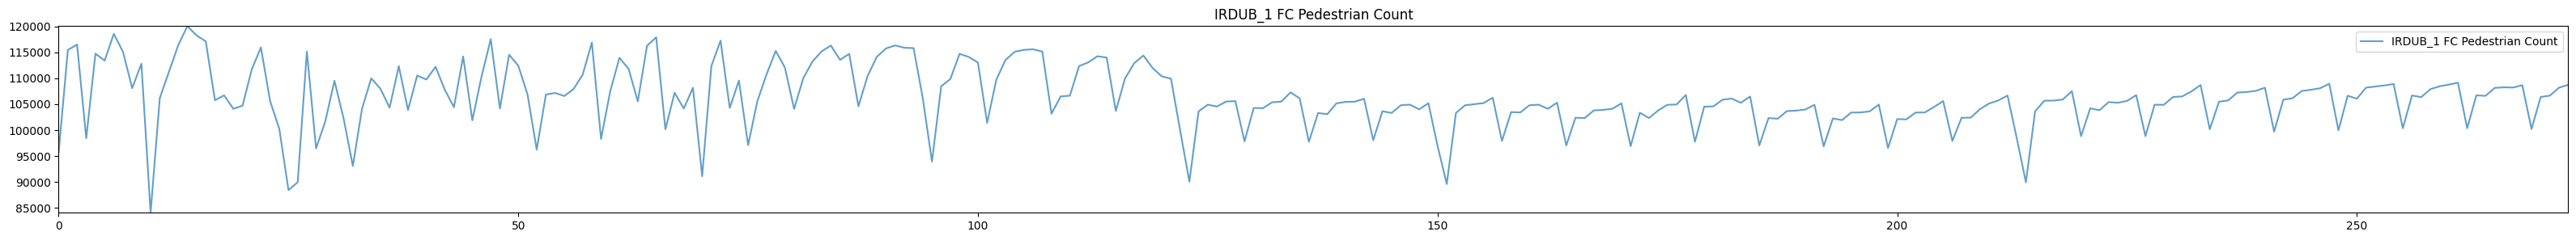

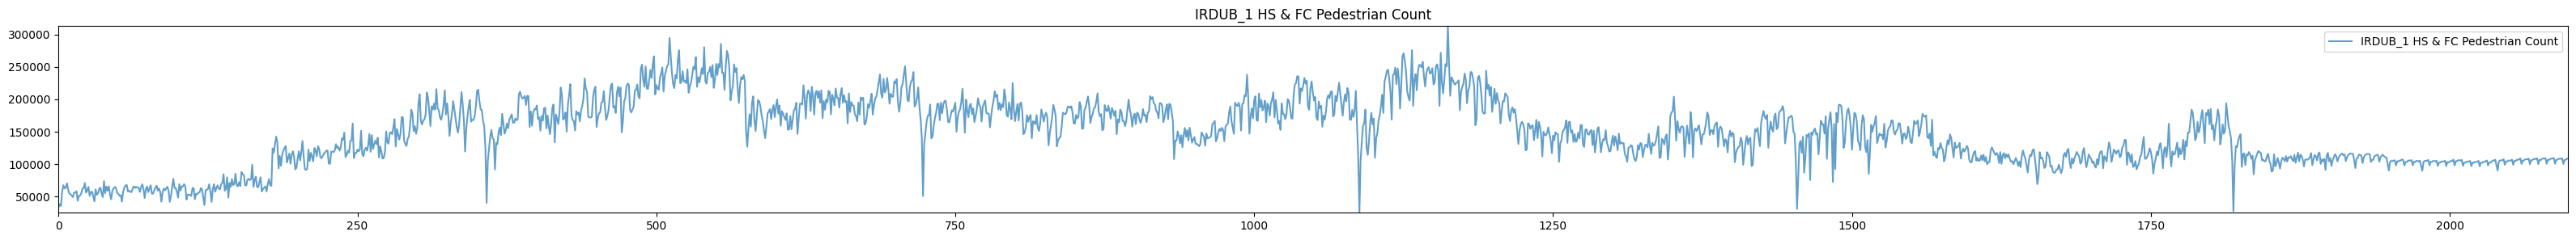

--------------------------------------------------------------------------IRDUB_3


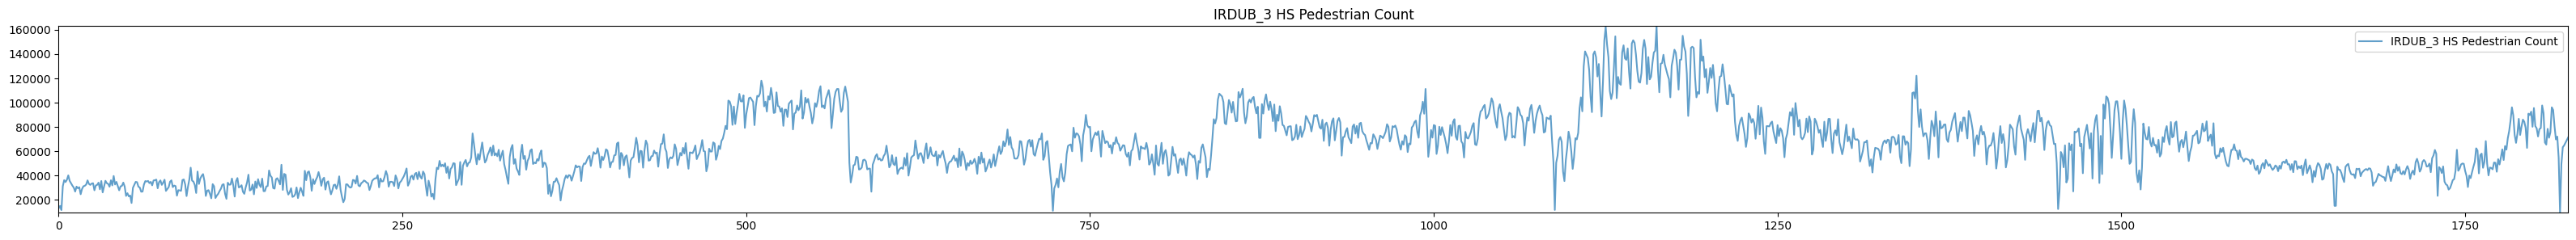

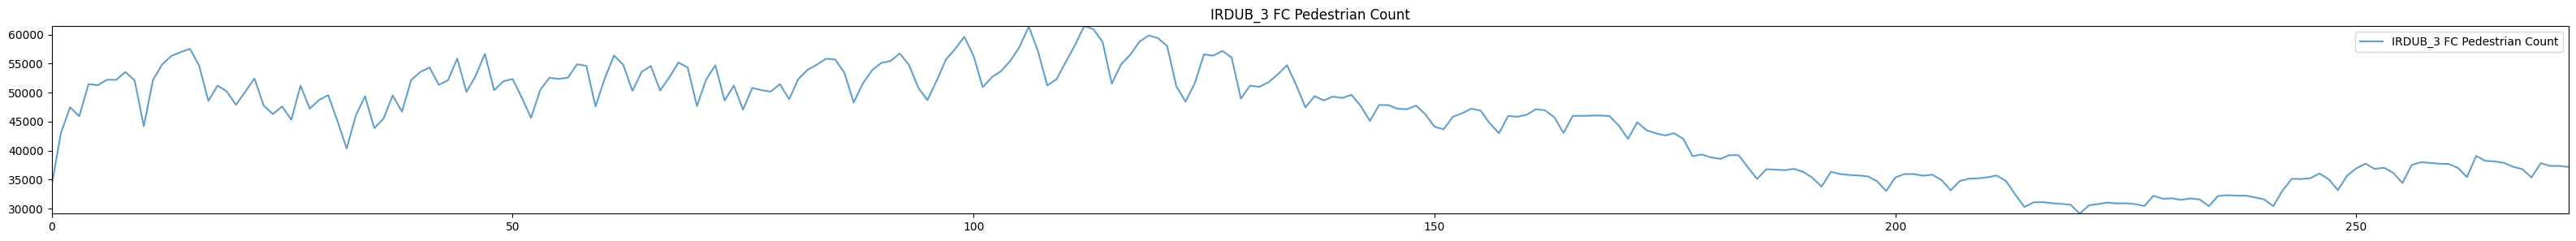

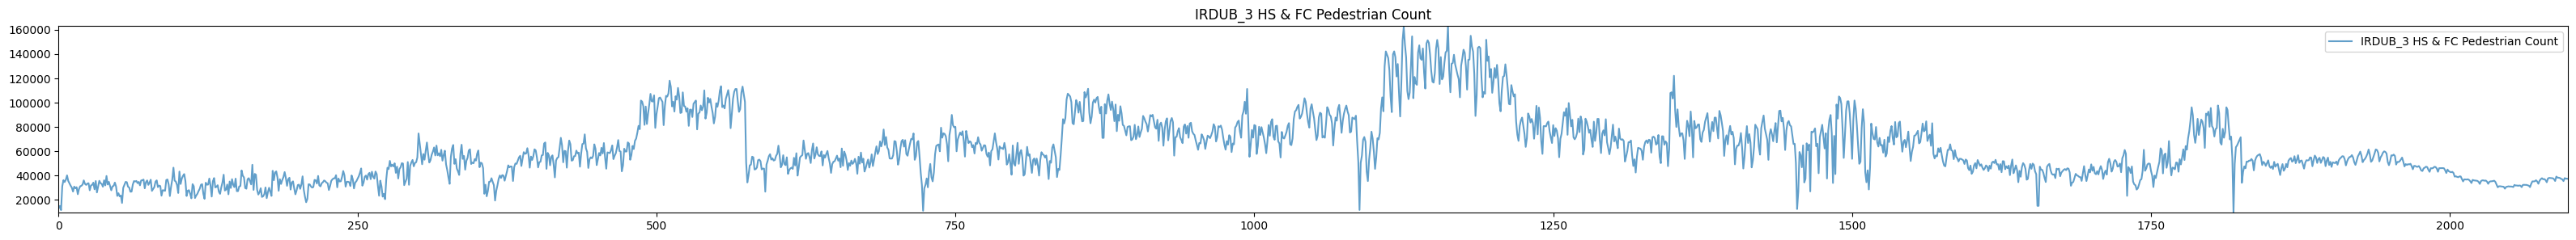

--------------------------------------------------------------------------IRDUB_4


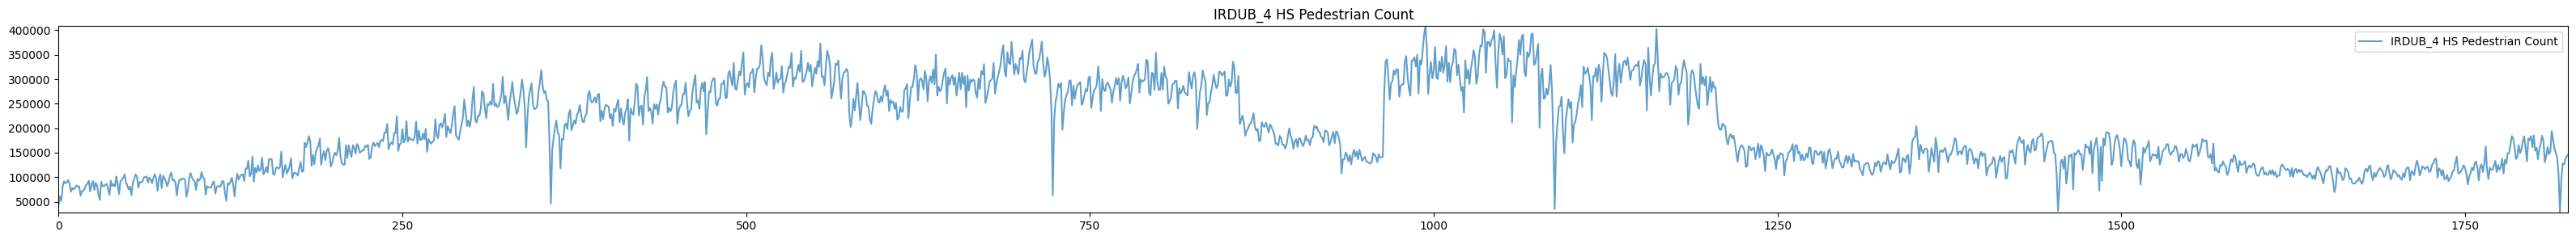

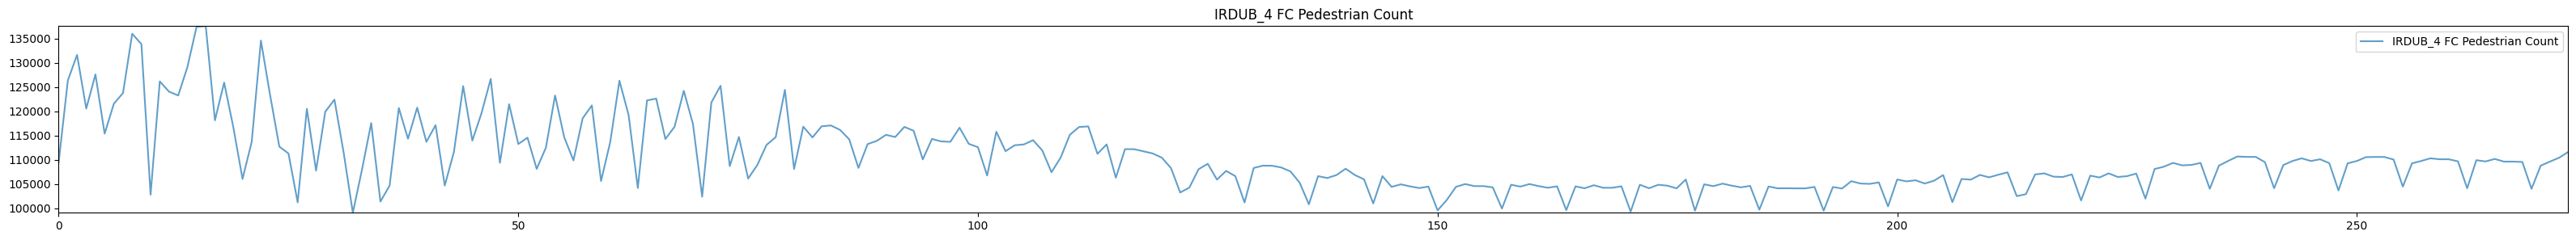

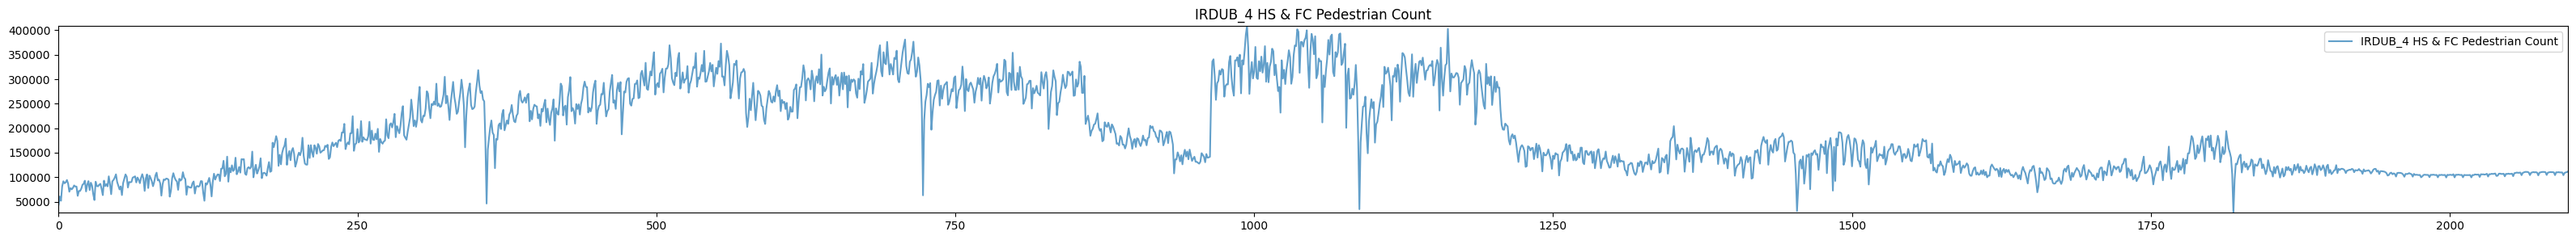

--------------------------------------------------------------------------IRDUB_5


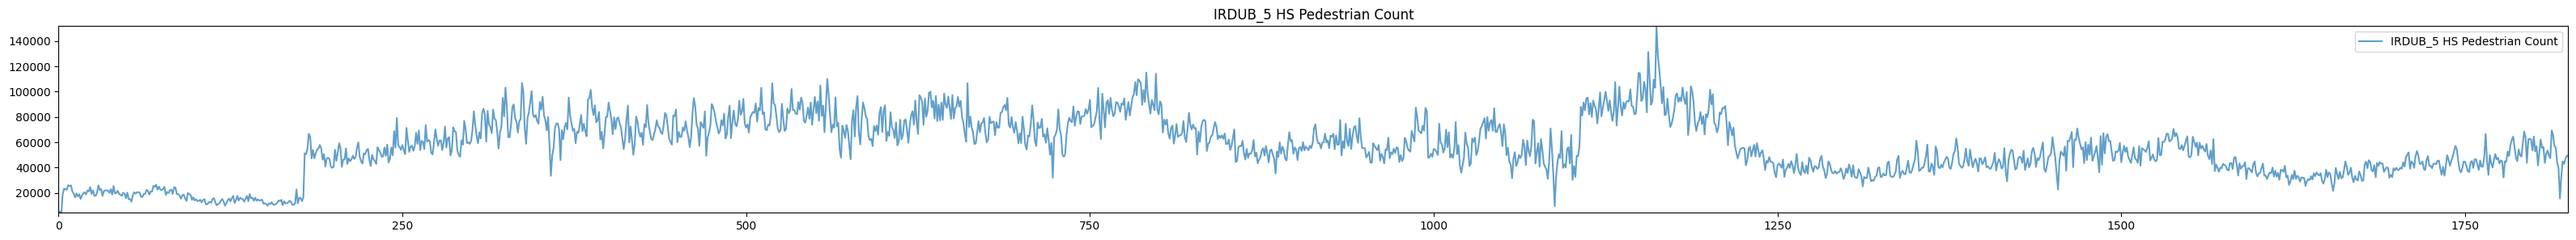

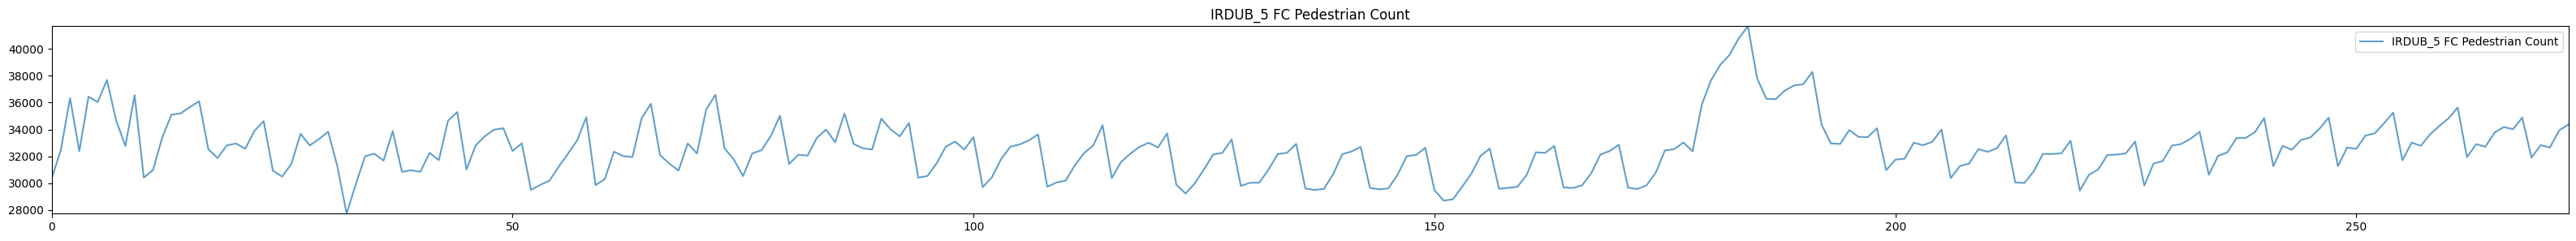

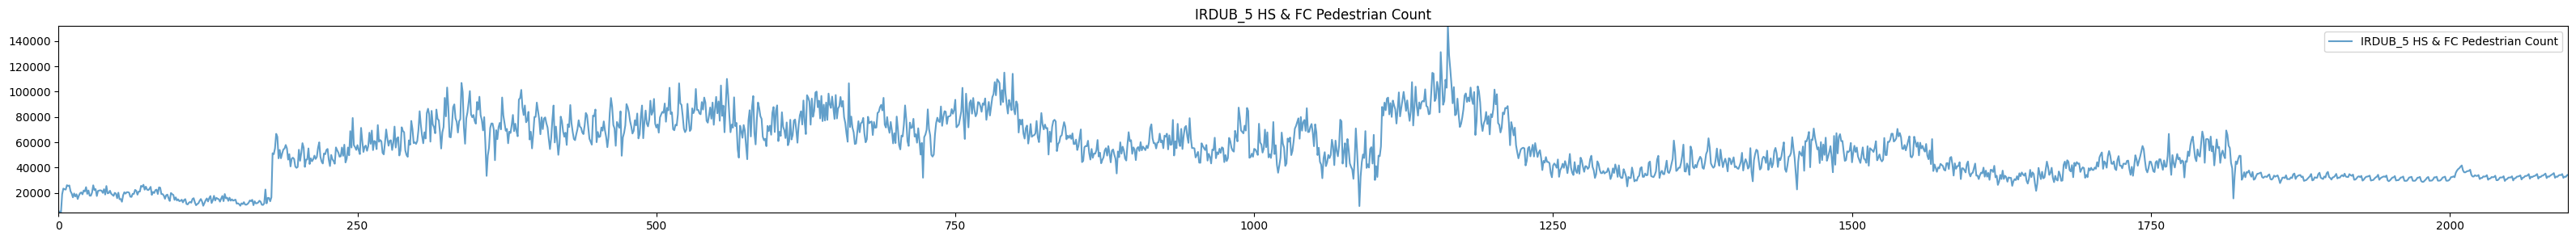

--------------------------------------------------------------------------IRDUB_8


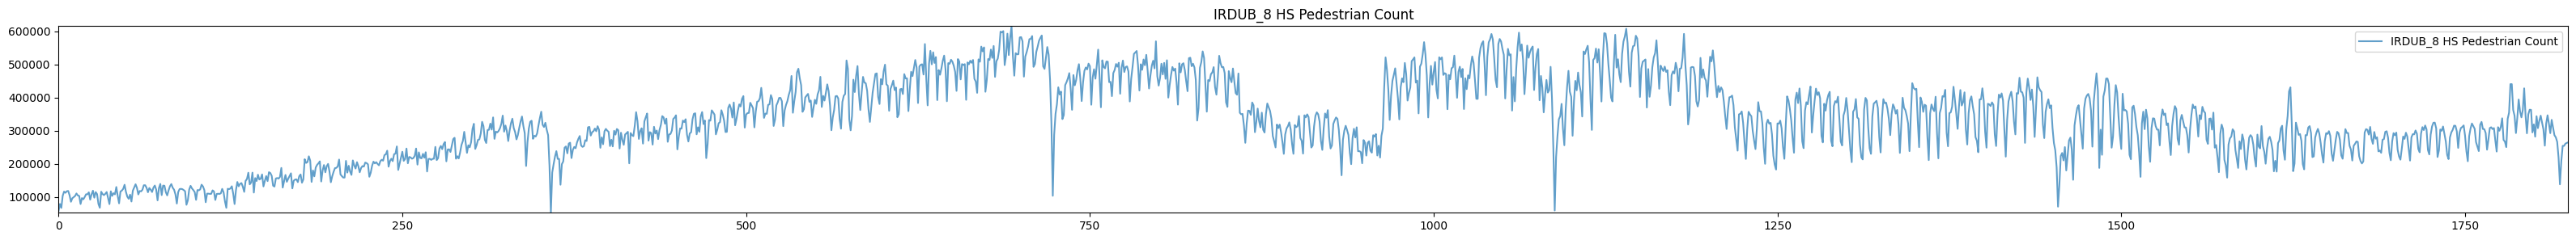

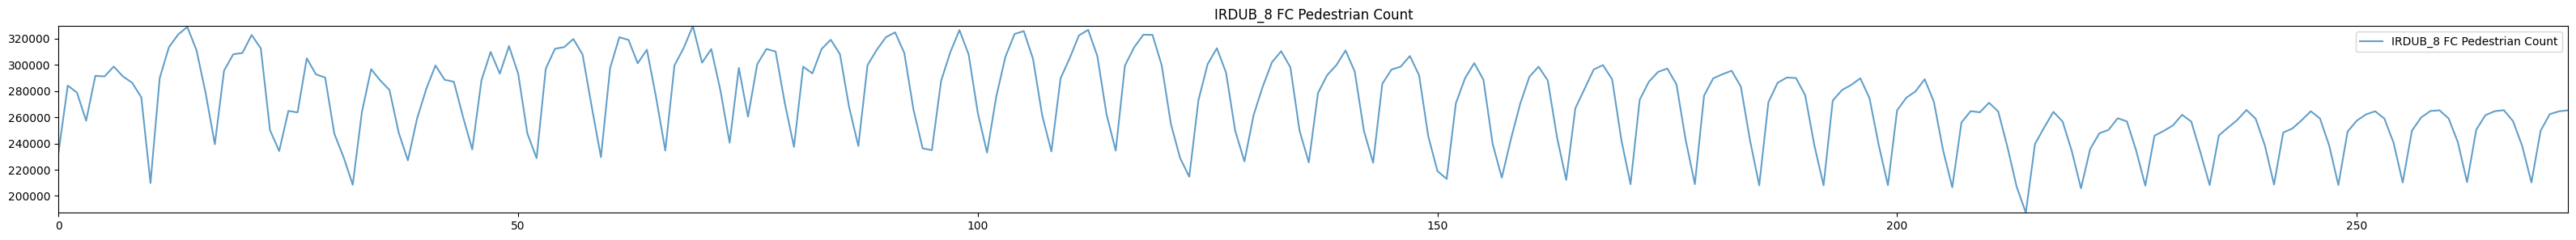

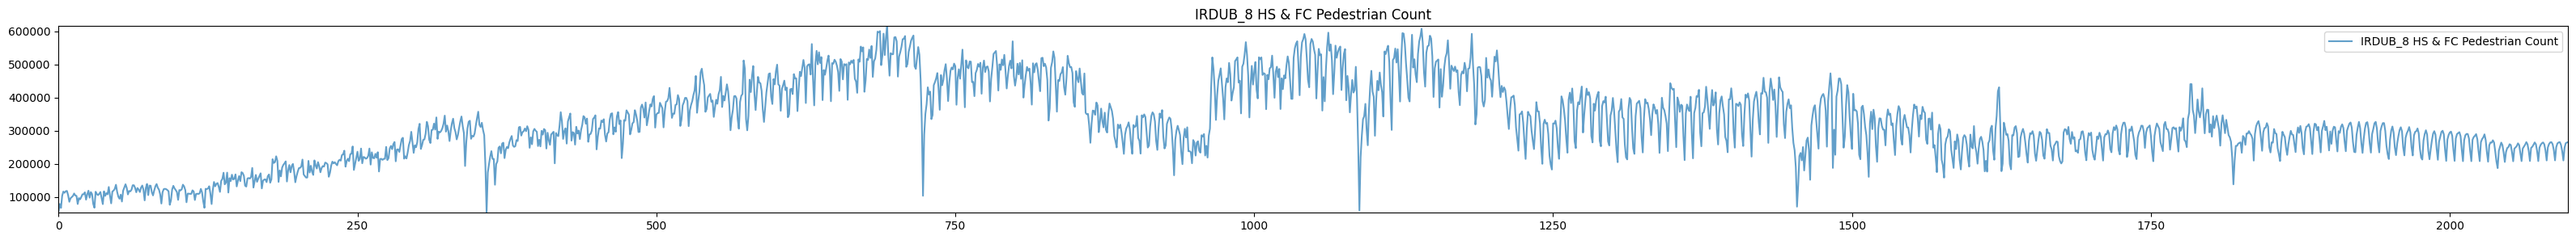

--------------------------------------------------------------------------NZAUK_1


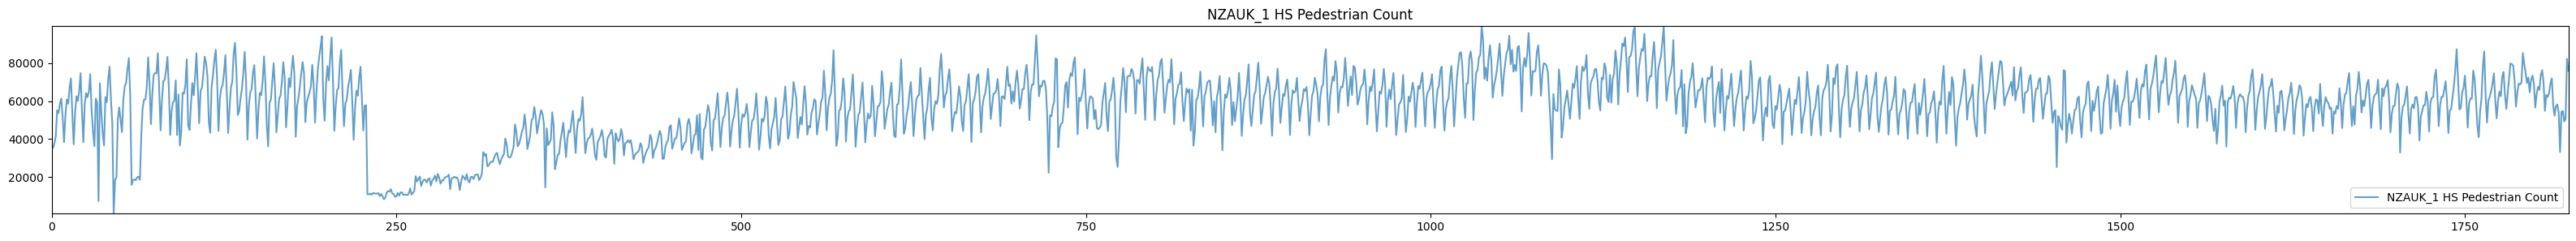

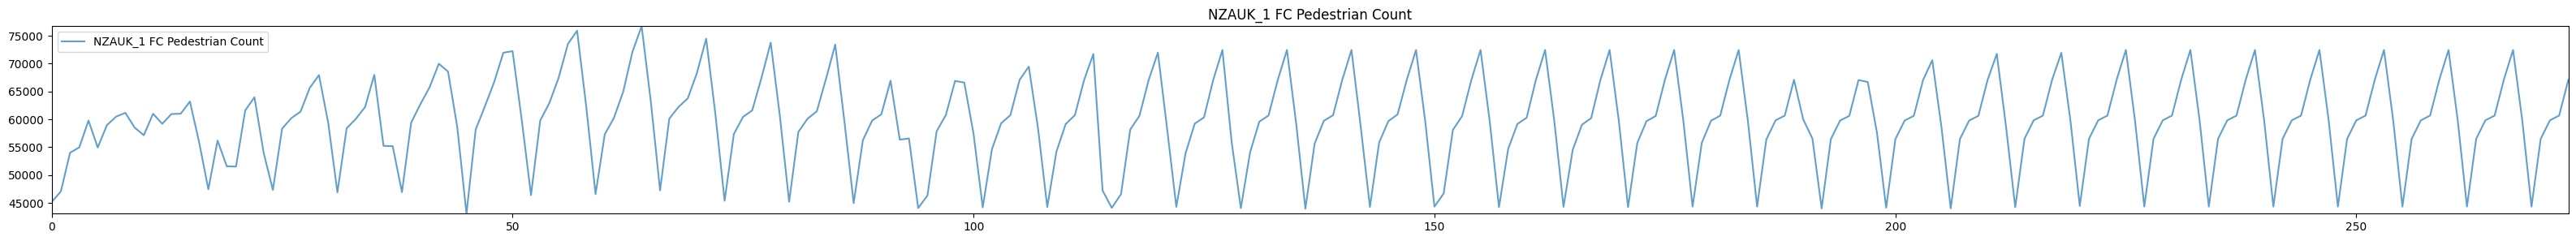

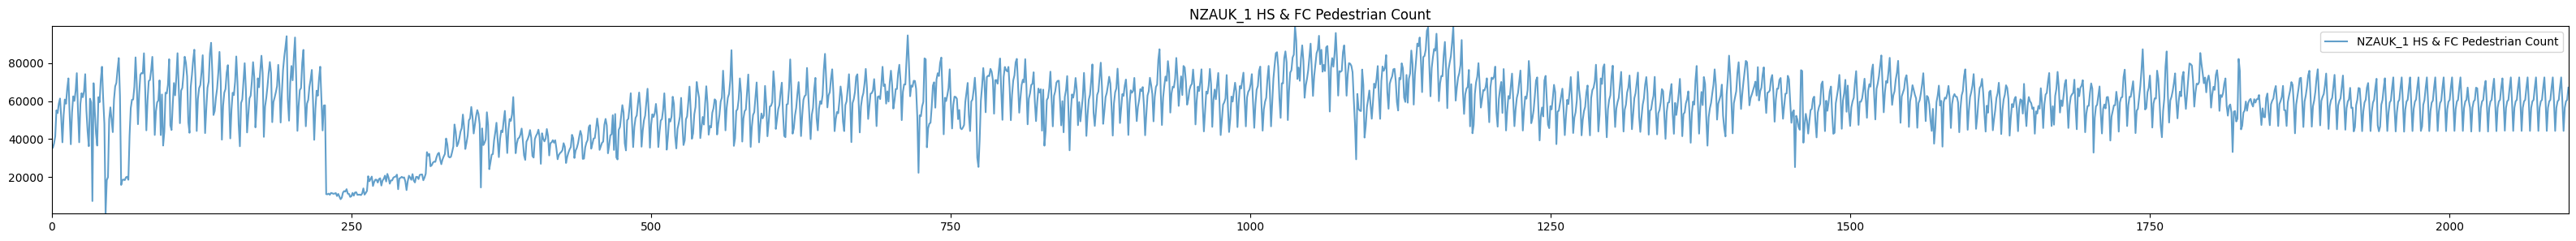

--------------------------------------------------------------------------NZAUK_5


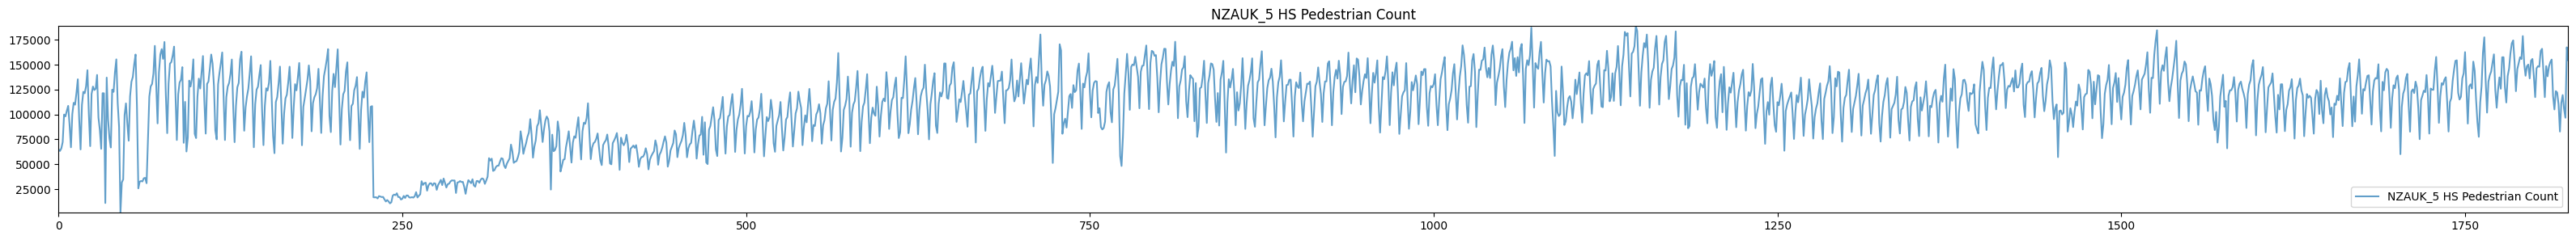

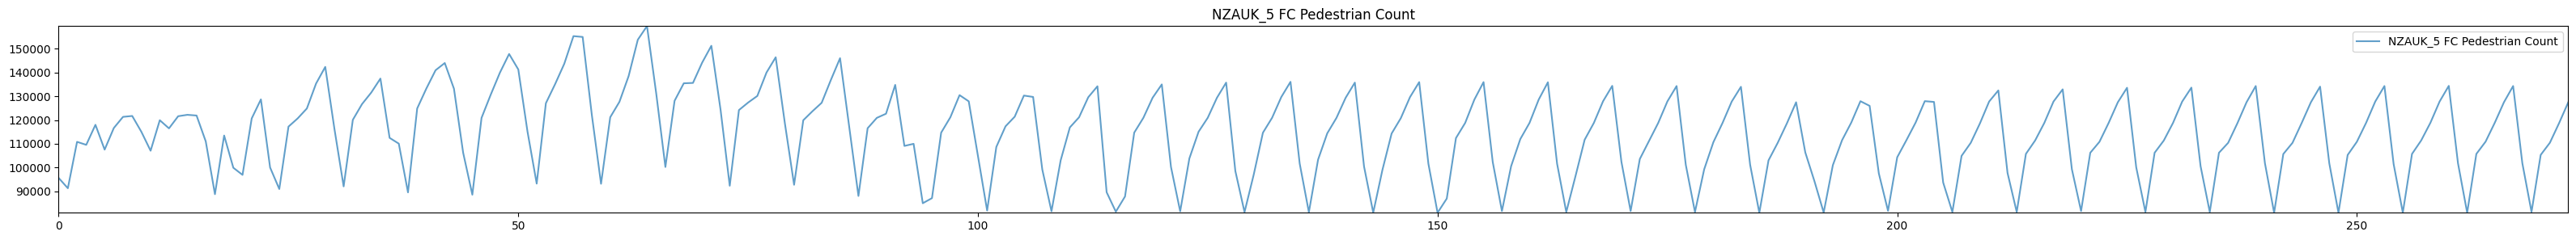

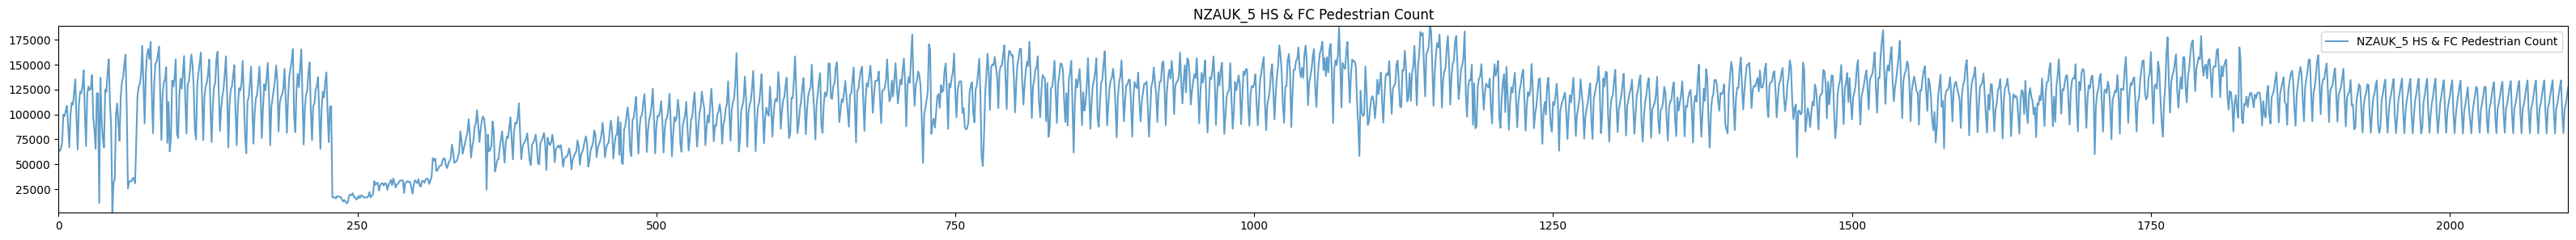

--------------------------------------------------------------------------NZAUK_6


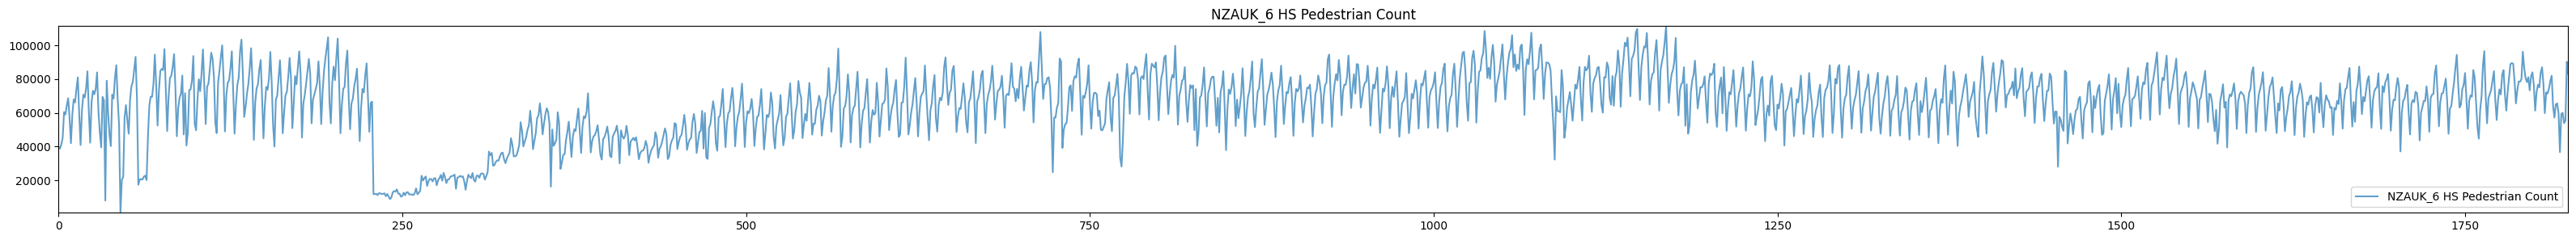

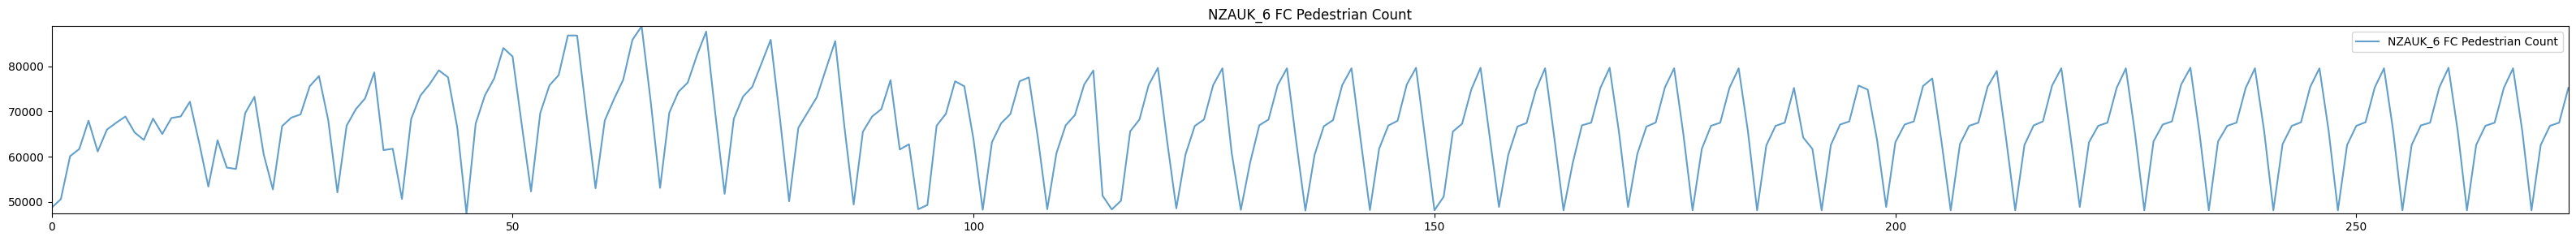

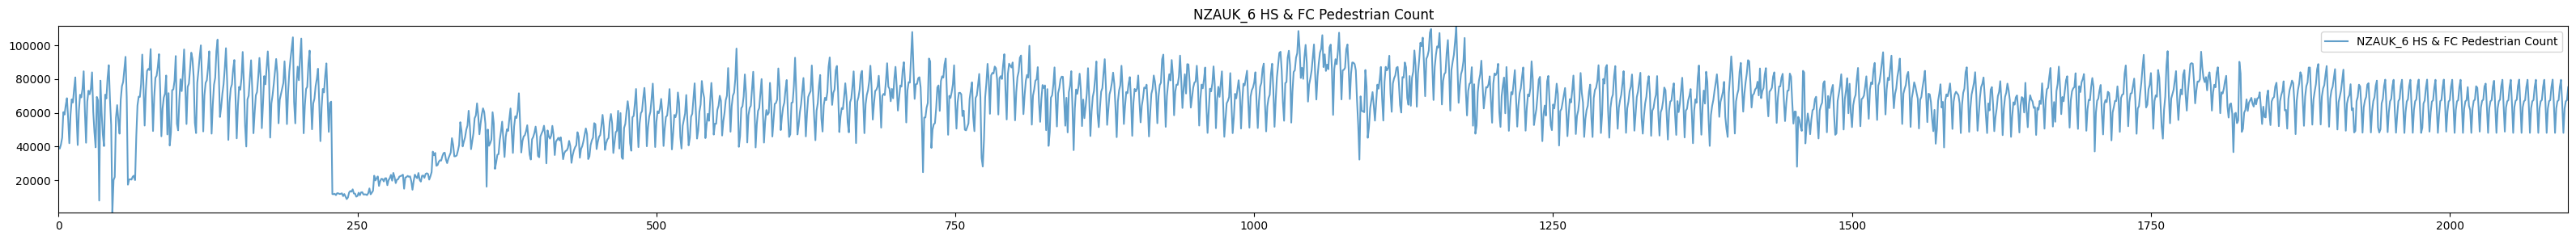

--------------------------------------------------------------------------NZAUK_7


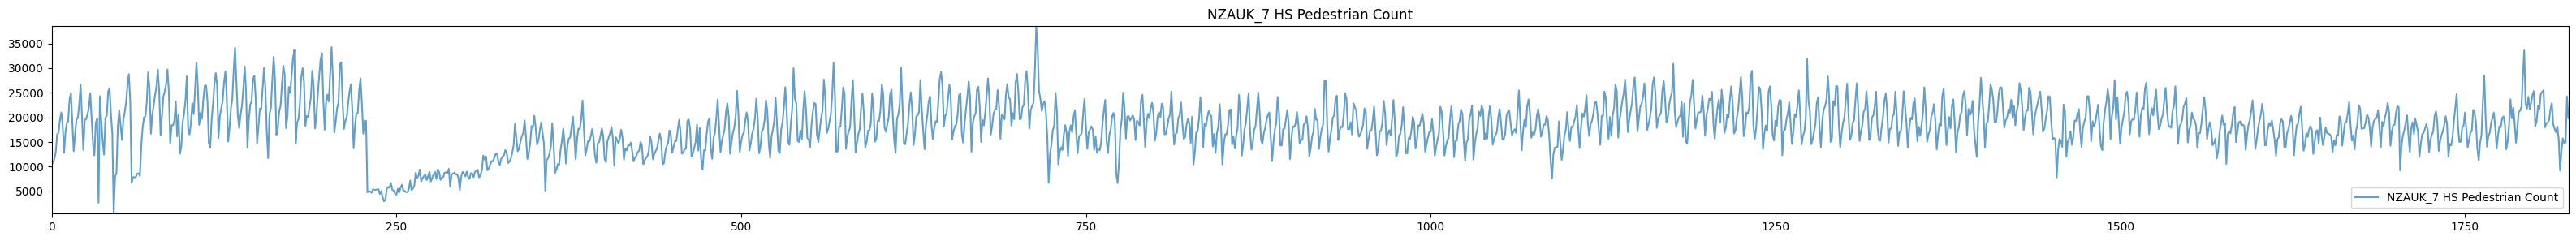

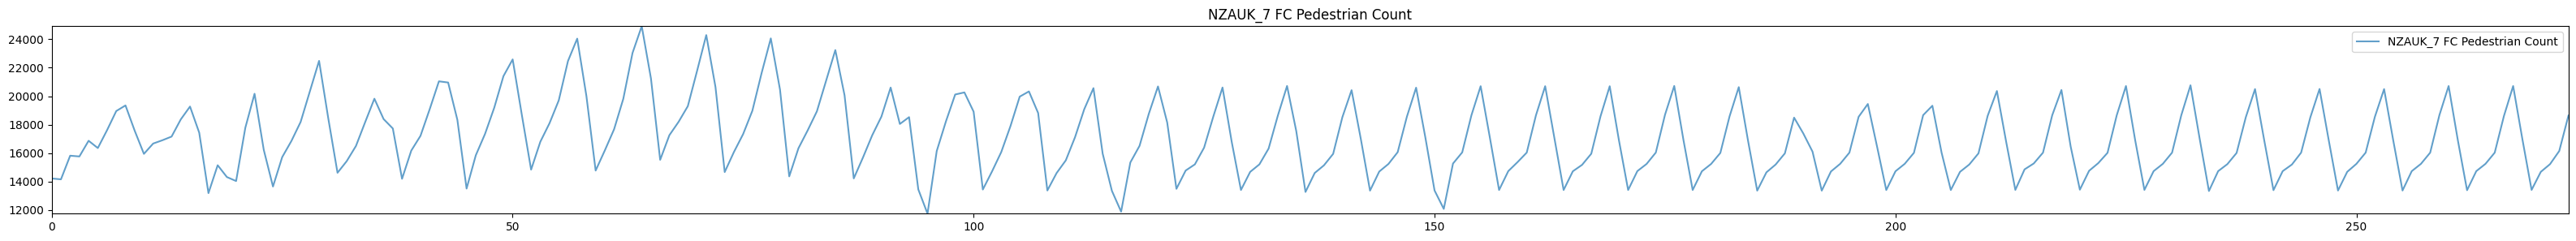

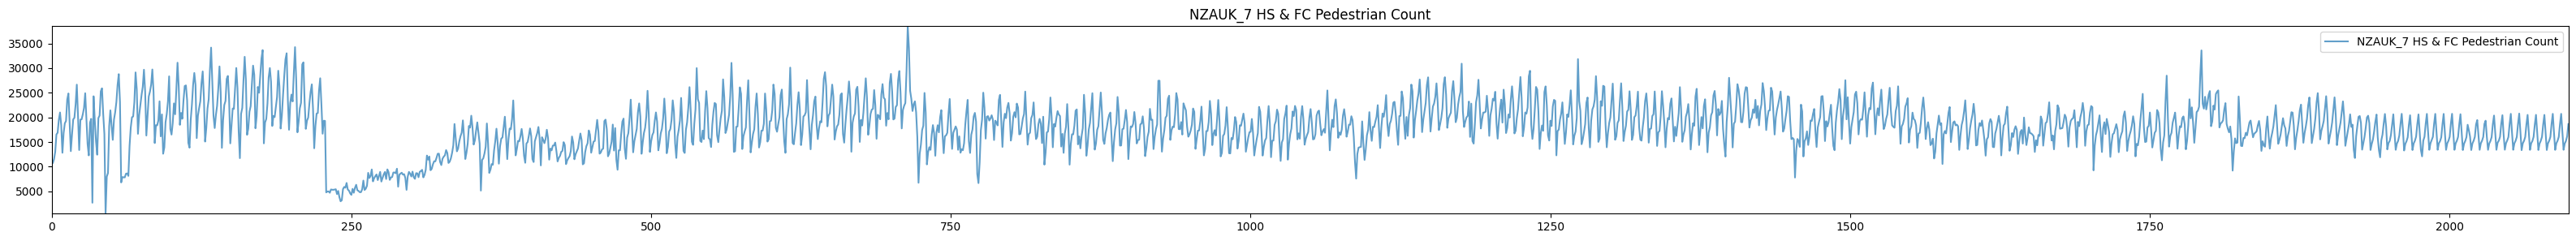

In [16]:
for tup in filename:
    print(f"--------------------------------------------------------------------------{tup[4]}")
    fr = forecast_for_location(tup[0],tup[1],tup[2],tup[3])
    testfull = df[df['Location_ID'] == tup[4]].sort_values('Date').reset_index(drop=True)[TARGET]
    plt.figure(figsize=(40,3))
    plt.margins(x=0,y=0)
    plt.plot(testfull, label=f'{tup[4]} HS Pedestrian Count', alpha=0.7)
    plt.legend()
    plt.title(f'{tup[4]} HS Pedestrian Count')

    plt.figure(figsize=(40,3))
    plt.margins(x=0,y=0)
    plt.plot(fr[TARGET], label=f'{tup[4]} FC Pedestrian Count', alpha=0.7)
    plt.legend()
    plt.title(f'{tup[4]} FC Pedestrian Count')
    
    plt.figure(figsize=(40,3))
    plt.margins(x=0,y=0)
    plt.plot(pd.concat([testfull,fr[TARGET],]).reset_index(drop=True), label=f'{tup[4]} HS & FC Pedestrian Count', alpha=0.7)
    plt.legend()
    plt.title(f'{tup[4]} HS & FC Pedestrian Count')

    plt.show()